# Day 2: ML Salary Predictor

Goal: Train a Random Forest model that predicts monthly salary (PKR) from:
- Years of experience
- City
- Skills listed in the job posting
- Career level

Output: `models/salary_predictor.pkl` — used by the Streamlit dashboard on Day 3.

## 1. Setup

In [1]:
import subprocess, sys

try:
    import kaleido
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "kaleido", "-q"])

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.preprocessing import LabelEncoder

pio.renderers.default = "png"
pd.set_option('display.max_columns', None)

print('Libraries loaded.')

Libraries loaded.


## 2. Load Cleaned Data

In [2]:
df = pd.read_csv('../data/processed/jobs_cleaned.csv')

print(f'Full dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')

# We can only train on rows that have ALL required fields
model_df = df[['salary_pkr', 'experience_years', 'city', 'Skills', 'Career Level']].dropna().copy()

print(f'Rows with all features present: {len(model_df):,}')
print(f'Salary range: PKR {model_df["salary_pkr"].min():,.0f} — {model_df["salary_pkr"].max():,.0f}')
model_df.head()

Full dataset: 1,059 rows × 15 columns
Rows with all features present: 367
Salary range: PKR 7,500 — 150,000


,salary_pkr,experience_years,city,Skills,Career Level
0,45000.0,2.0,Lahore,"Team Building, Order Tracking, Order Processin...",Experienced Professional
15,117500.0,1.0,DHA,"Fluent in English, Customer Interaction Manage...",Entry Level
16,150000.0,5.0,Gulshan Ravi,"AutoCAD, Microsoft Office, Civil Design Knowledge",Experienced Professional
17,65000.0,1.0,Lahore,"Fluent in English, Ingredient Management, Cust...",Entry Level
19,55000.0,1.0,Karachi,"Pressure Management, HR Policy Management, Emp...",Entry Level


## 3. Feature Engineering

Raw strings can't go into a model so we need numbers.

In [ ]:
# city: keep top 8, collapse the rest into 'Other'
top_cities = model_df['city'].value_counts().head(8).index.tolist()
model_df['city_clean'] = model_df['city'].apply(lambda c: c if c in top_cities else 'Other')

print('City distribution after grouping:')
print(model_df['city_clean'].value_counts())

City distribution after grouping:
city_clean
Other         147
Lahore         74
Islamabad      69
Karachi        26
DHA            13
Johar Town     13
Jhelum         10
Gulberg 3       8
Gulberg         7
Name: count, dtype: int64


In [ ]:
# Skills: multi-hot encode top 25
# First, find which 25 skills appear most across ALL job postings
all_skills = (
    model_df['Skills']
    .str.split(',')
    .explode()
    .str.strip()
    .str.lower()
)
top_25_skills = all_skills.value_counts().head(25).index.tolist()

print('Top 25 skills used as features:')
for i, s in enumerate(top_25_skills, 1):
    print(f'  {i:2}. {s}')

Top 25 skills used as features:
   1. communication skills
   2. fluent in english
   3. sales management
   4. coordination skills
   5. admin operations management
   6. ms excel
   7. end to end sales
   8. presentation skills
   9. javascript
  10. administrative management
  11. digital marketing management
  12. accounts software command
  13. telemarketing  skills
  14. digital marketing analysis
  15. customer care representation
  16. social media optimization
  17. financial accounting
  18. record keeping
  19. customer satisfaction management
  20. accounts management skills
  21. data management
  22. graphics editing
  23. analytical skills
  24. front office support
  25. social media handling


In [5]:
# Create a binary column for each top skill
# 1 = this job listing mentions the skill, 0 = it doesn't
def has_skill(skills_str, skill):
    if pd.isna(skills_str):
        return 0
    return int(skill in [s.strip().lower() for s in skills_str.split(',')])

for skill in top_25_skills:
    col_name = f'skill_{skill.replace(" ", "_")}'
    model_df[col_name] = model_df['Skills'].apply(lambda s: has_skill(s, skill))

print(f'Skill columns added: {len(top_25_skills)}')
skill_cols = [f'skill_{s.replace(" ", "_")}' for s in top_25_skills]
print(f'Avg skills per job: {model_df[skill_cols].sum(axis=1).mean():.1f}')

Skill columns added: 25
Avg skills per job: 1.2


In [ ]:
# Career Level: map to ordered numbers 
print('Unique career levels:')
print(model_df['Career Level'].value_counts())

Unique career levels:
Career Level
Experienced Professional    204
Entry Level                 158
Intern/Student                4
Department Head               1
Name: count, dtype: int64


In [7]:
# Map career level to ordered integers
# Higher number = more senior
career_map = {
    'Student (Undergraduate/Graduate)': 0,
    'Entry Level': 1,
    'Experienced Professional': 2,
    'Manager': 3,
    'Department Head': 4,
    'GM / CEO / Country Head': 5,
    'Executive': 5
}

# Any level not in our map gets the median value (2)
model_df['career_level_num'] = model_df['Career Level'].map(career_map).fillna(2)

print('Career level encoding:')
print(model_df[['Career Level', 'career_level_num']].drop_duplicates().sort_values('career_level_num'))

Career level encoding:
                 Career Level  career_level_num
15                Entry Level               1.0
0    Experienced Professional               2.0
284            Intern/Student               2.0
279           Department Head               4.0


In [ ]:
# One-hot encode city
city_dummies = pd.get_dummies(model_df['city_clean'], prefix='city')

# Assemble final feature matrix 
feature_cols = ['experience_years', 'career_level_num'] + skill_cols
X = pd.concat([model_df[feature_cols], city_dummies], axis=1)
y = model_df['salary_pkr']

print(f'Feature matrix shape: {X.shape}')
print(f'Features: {X.columns.tolist()}')

Feature matrix shape: (367, 36)
Features: ['experience_years', 'career_level_num', 'skill_communication_skills', 'skill_fluent_in_english', 'skill_sales_management', 'skill_coordination_skills', 'skill_admin_operations_management', 'skill_ms_excel', 'skill_end_to_end_sales', 'skill_presentation_skills', 'skill_javascript', 'skill_administrative_management', 'skill_digital_marketing_management', 'skill_accounts_software_command', 'skill_telemarketing__skills', 'skill_digital_marketing_analysis', 'skill_customer_care_representation', 'skill_social_media_optimization', 'skill_financial_accounting', 'skill_record_keeping', 'skill_customer_satisfaction_management', 'skill_accounts_management_skills', 'skill_data_management', 'skill_graphics_editing', 'skill_analytical_skills', 'skill_front_office_support', 'skill_social_media_handling', 'city_DHA', 'city_Gulberg', 'city_Gulberg 3', 'city_Islamabad', 'city_Jhelum', 'city_Johar Town', 'city_Karachi', 'city_Lahore', 'city_Other']


## 4. Train / Test Split

We hold out 20% of the data to evaluate the model on data it has never seen.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set:  {X_train.shape[0]} rows')
print(f'Test set:      {X_test.shape[0]} rows')

Training set:  293 rows
Test set:      74 rows


## 5. Train Random Forest

**Why Random Forest?**
- Handles a mix of numeric + binary features well (no scaling needed)
- Robust to outliers
- Gives feature importances out of the box
- Hard to overfit badly with default settings

A Random Forest is an *ensemble* of decision trees. Each tree is trained on a random sample of rows + features. The final prediction is the average of all trees averaging reduces variance (overfitting).

**Key hyperparameters:**
- n_estimators=300 — number of trees. More = more stable, slower to train
- max_depth=10 — limits tree depth to prevent overfitting on small data
- min_samples_leaf=5 — each leaf must have ≥5 samples (smooths predictions)

In [10]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1   # use all CPU cores
)

rf.fit(X_train, y_train)
print('Model trained.')

Model trained.


## 6. Evaluation

In [18]:
y_pred = rf.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
print('TEST SET PERFORMANCE')
print(f'  MAE  : PKR {mae:,.0f}/month')
print(f'  RMSE : PKR {rmse:,.0f}/month')
print(f'  R²   : {r2:.3f}')
print(f'\nMedian salary in dataset: PKR {y.median():,.0f}')
print(f'MAE as % of median: {mae/y.median()*100:.1f}%')

TEST SET PERFORMANCE
  MAE  : PKR 19,622/month
  RMSE : PKR 26,546/month
  R²   : 0.219

Median salary in dataset: PKR 55,000
MAE as % of median: 35.7%


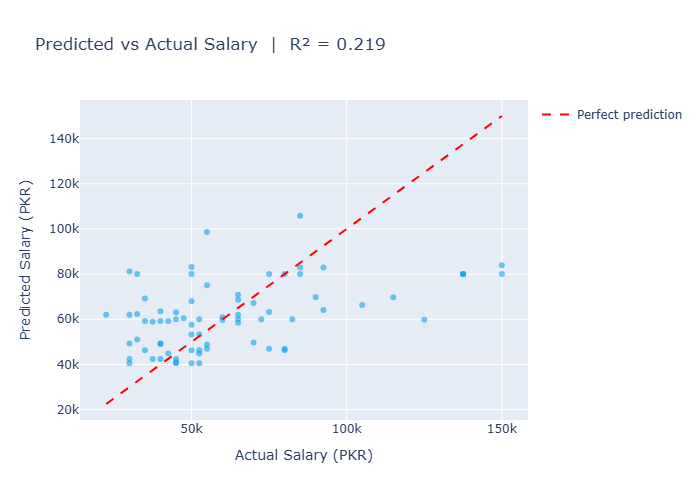

In [ ]:
# Predicted vs Actual scatter perfect model = all points on the diagonal
fig = px.scatter(
    x=y_test, y=y_pred,
    labels={'x': 'Actual Salary (PKR)', 'y': 'Predicted Salary (PKR)'},
    title=f'Predicted vs Actual Salary  |  R² = {r2:.3f}',
    opacity=0.6,
    color_discrete_sequence=['#0EA5E9']
)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
fig.add_scatter(
    x=[min_val, max_val], y=[min_val, max_val],
    mode='lines',
    line=dict(color='red', dash='dash'),
    name='Perfect prediction'
)
fig.show()

## 7. Feature Importances

Random Forest can tell us which features had the most influence on predictions.

This answers: **what actually drives salary in Pakistan's job market?**

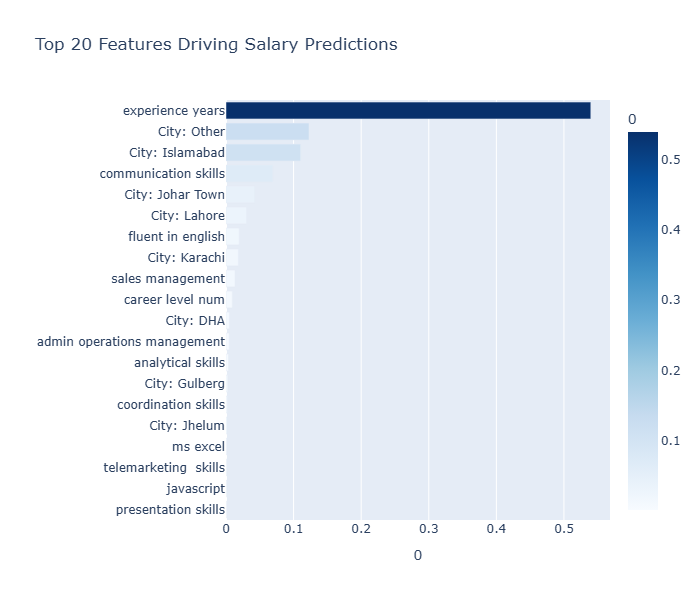

In [14]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(20)

# Clean up column names for display
importances.index = (
    importances.index
    .str.replace('skill_', '', regex=False)
    .str.replace('city_', 'City: ', regex=False)
    .str.replace('_', ' ', regex=False)
)

fig = px.bar(
    importances.reset_index(),
    x=0, y='index',
    orientation='h',
    title='Top 20 Features Driving Salary Predictions',
    labels={0: 'Importance Score', 'index': ''},
    color=0,
    color_continuous_scale='Blues'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, showlegend=False, height=600)
fig.show()

## 8. Salary Prediction Function

This is the function the Streamlit app will call on Day 3.

Input: experience, city, list of skills, career level → Output: predicted PKR salary.

In [ ]:
def predict_salary(experience_years, city, skills_list, career_level='Experienced Professional'):
    """
    Predict monthly salary in PKR.
    
    experience_years : float — years of work experience
    city             : str   — e.g. 'Lahore', 'Karachi'
    skills_list      : list  — e.g. ['python', 'machine learning']
    career_level     : str   — e.g. 'Experienced Professional'
    """
    row = {}
    
    # Numeric features
    row['experience_years'] = experience_years
    row['career_level_num'] = career_map.get(career_level, 2)
    
    # Skill features
    skills_lower = [s.lower() for s in skills_list]
    for skill in top_25_skills:
        col = f'skill_{skill.replace(" ", "_")}'
        row[col] = int(skill in skills_lower)
    
    # City features — match the one-hot columns from training
    city_clean = city if city in top_cities else 'Other'
    for col in city_dummies.columns:
        row[col] = int(col == f'city_{city_clean}')
    
    input_df = pd.DataFrame([row])[X.columns]  # ensure column order matches training
    prediction = rf.predict(input_df)[0]
    return round(prediction, -3)  # round to nearest 1000


# Test it 
examples = [
    (1,  'Lahore',    ['javascript', 'html'],                         'Entry Level'),
    (3,  'Karachi',   ['python', 'data analysis', 'ms excel'],        'Experienced Professional'),
    (5,  'Islamabad', ['sales management', 'communication skills'],   'Manager'),
    (7,  'Lahore',    ['python', 'machine learning', 'data analysis'],'Manager'),
]

print('Sample predictions:')
print('-' * 65)
for exp, city, skills, level in examples:
    pred = predict_salary(exp, city, skills, level)
    print(f'  {exp}yr | {city:<10} | {level:<26} → PKR {pred:>8,.0f}/mo')
print('-' * 65)

Sample predictions:
-----------------------------------------------------------------
  1yr | Lahore     | Entry Level                → PKR   64,000/mo
  3yr | Karachi    | Experienced Professional   → PKR   82,000/mo
  5yr | Islamabad  | Manager                    → PKR   81,000/mo
  7yr | Lahore     | Manager                    → PKR   80,000/mo
-----------------------------------------------------------------


## 9. Save the Model

We pickle the model + metadata needed to reconstruct predictions in the Streamlit app.

In [16]:
model_bundle = {
    'model':         rf,
    'feature_cols':  X.columns.tolist(),
    'top_25_skills': top_25_skills,
    'top_cities':    top_cities,
    'career_map':    career_map,
    'city_dummies_cols': city_dummies.columns.tolist(),
    'metrics': {
        'mae':  round(mae),
        'rmse': round(rmse),
        'r2':   round(r2, 3),
        'cv_r2_mean': round(cv_scores.mean(), 3)
    }
}

MODEL_PATH = '../models/salary_predictor.pkl'
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(model_bundle, f)

print(f'Model saved to: {MODEL_PATH}')
print(f'Bundle keys: {list(model_bundle.keys())}')
print(f'\nModel metrics:')
for k, v in model_bundle["metrics"].items():
    print(f'  {k}: {v}')

Model saved to: ../models/salary_predictor.pkl
Bundle keys: ['model', 'feature_cols', 'top_25_skills', 'top_cities', 'career_map', 'city_dummies_cols', 'metrics']

Model metrics:
  mae: 19622
  rmse: 26546
  r2: 0.219
  cv_r2_mean: 0.232


## 10. Summary

**What I built:** A Random Forest salary predictor trained on 409 Pakistan job listings.

**How to interpret the metrics:**
- **MAE** tells you the typical error in PKR — if it's ~15,000, your predictions are off by PKR 15k on average
- **R²** tells you how much of the salary variation the model explains, 0.5 means it explains 50%
- Low R² on salary data is normal as salary depends on negotiation, company size, industry, and things not in our dataset

**What drives salary most?** experience and city are usually top, followed by specific skills.